In [1]:
import pandas as pd

In [3]:
data=pd.read_csv('advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [4]:
data.shape

(200, 4)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
data.nunique().sort_values(ascending=False)

TV           190
Newspaper    172
Radio        167
Sales        121
dtype: int64

In [11]:
n_rows = len(data)
unique_cols = [c for c in data.columns if data[c].nunique(dropna=False) == n_rows]
print(unique_cols)

[]


In [12]:
near_unique_cols = [c for c in data.columns if data[c].nunique(dropna=False) > 0.95 * n_rows and c not in unique_cols]
print(near_unique_cols)

[]


In [15]:
threshold = 0.75 * len(data)
cols_with_majority_same = [col for col in data.columns if data[col].value_counts(dropna=False).max() >= threshold]
print("\
Columns with 75%+ same values:")
print(cols_with_majority_same)

Columns with 75%+ same values:
[]


In [17]:
print('na count:')
data.isna().sum().sort_values(ascending=False)

na count:


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [19]:
numeric_cols=data.select_dtypes(include=['float64','int64']).columns

def detect_outliers(x,column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-5*IQR
    upper_bound=Q3+5*IQR
    outliers=data[(data[column]<lower_bound)|(data[column]>upper_bound)]
    return outliers

outliers_summary={}
for col in numeric_cols:
    outliers=detect_outliers(data,col)
    outliers_summary[col]=len(outliers)

print('Outliers in numeric Columns:')
print(outliers_summary)

Outliers in numeric Columns:
{'TV': 0, 'Radio': 0, 'Newspaper': 0, 'Sales': 0}


In [22]:
dupicates=data[data.duplicated()]
print(f'Total dupicates: {dupicates.shape[0]}')

Total dupicates: 0


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


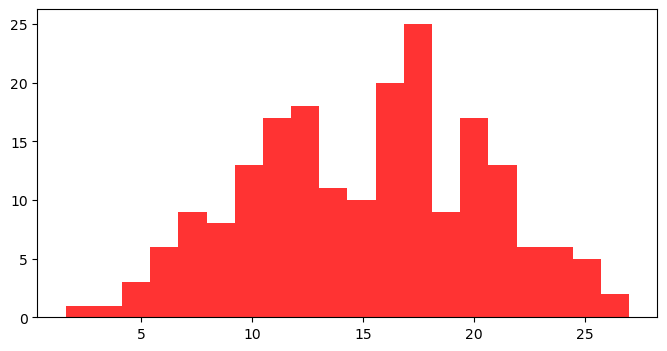

In [25]:
plt.figure(figsize=(8,4))
plt.hist(data['Sales'], bins=20,color='Red',alpha=0.8)
plt.show()

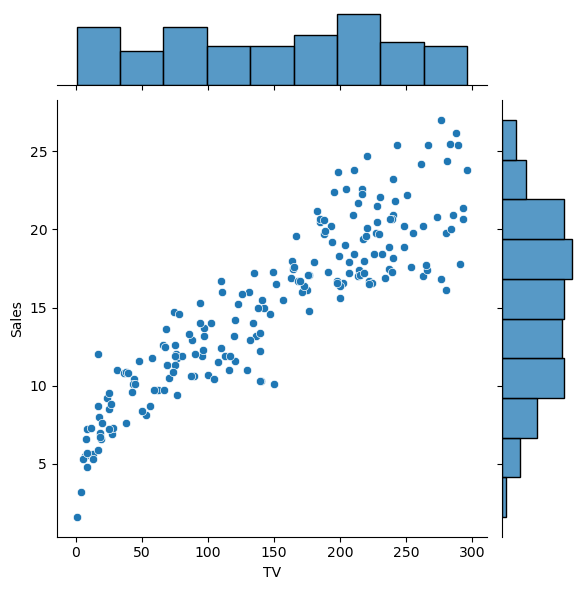

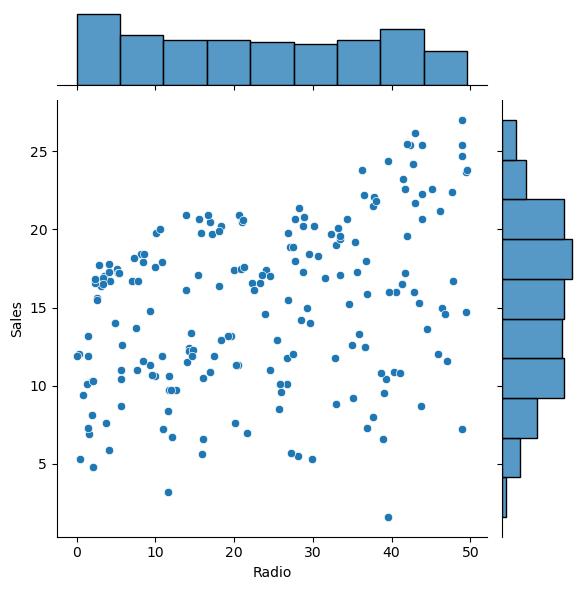

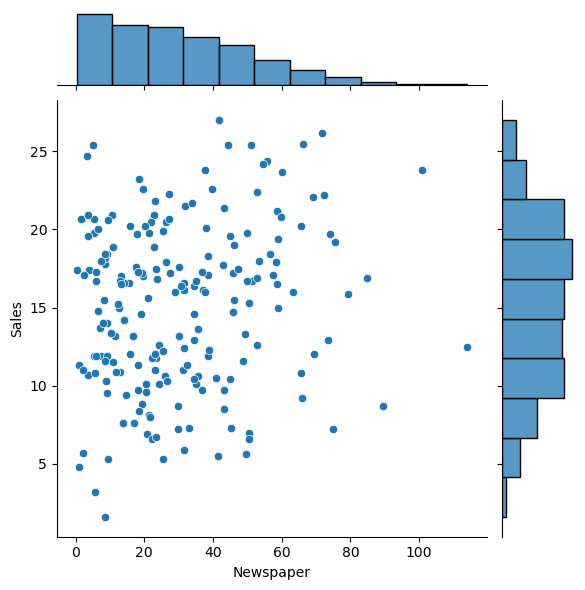

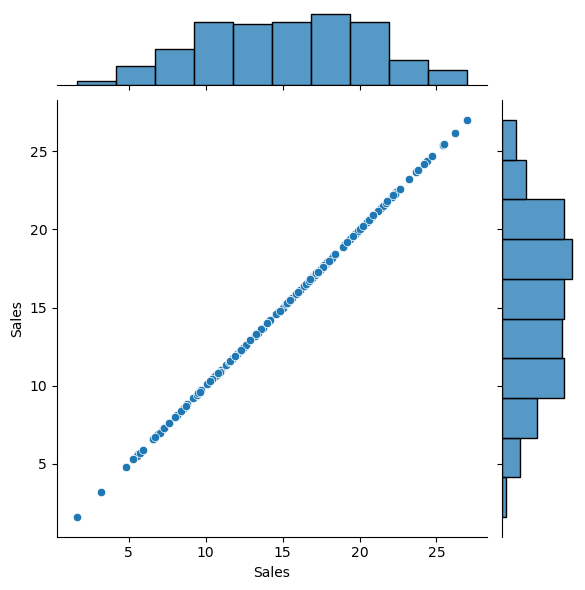

In [31]:
for col in data.select_dtypes(include=['number']).columns:
    sns.jointplot(data=data,x=col ,y='Sales',kind='scatter')
    plt.show

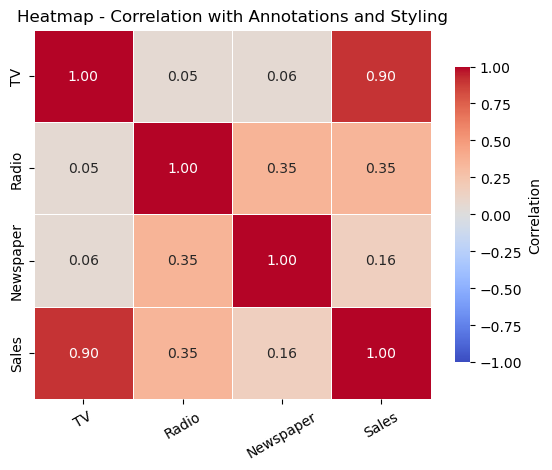

In [32]:
plt.figure()
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
plt.title('Heatmap - Correlation with Annotations and Styling')
plt.xticks(rotation=30)
plt.show()

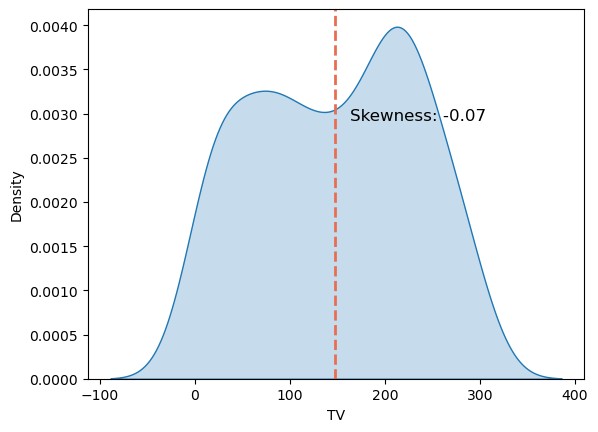

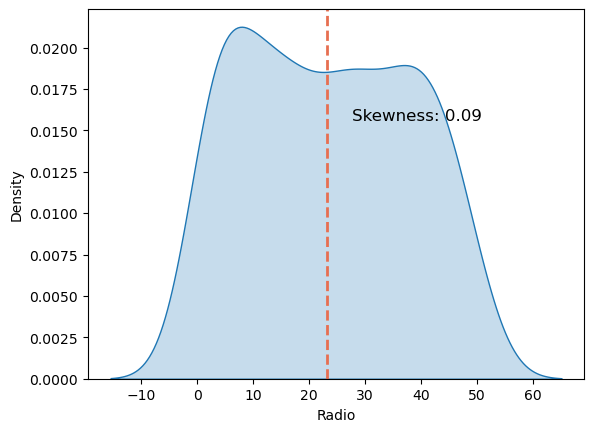

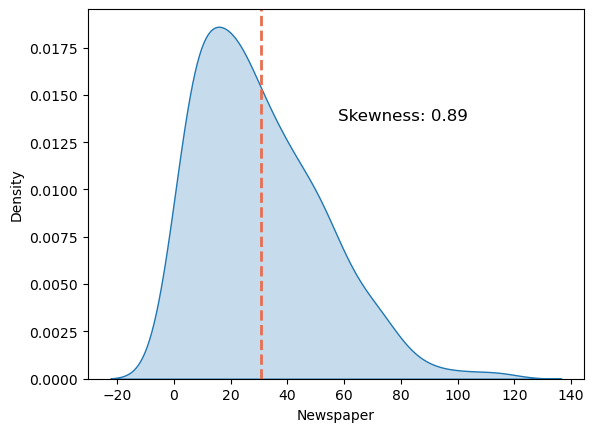

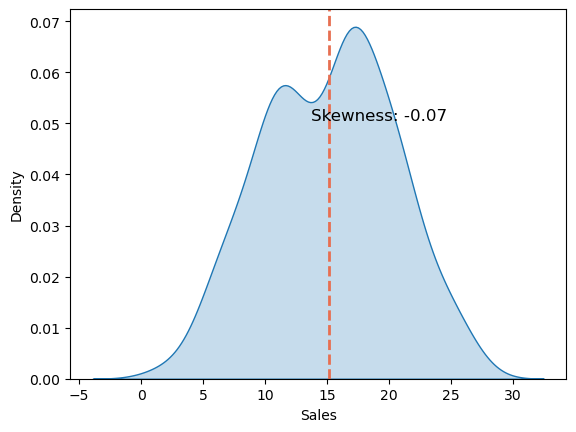

In [35]:
for col in data.select_dtypes(include=['number']).columns:
    sns.kdeplot(data[col], fill=True)
    plt.axvline(data[col].mean(), color='#e76f51', linestyle='--', linewidth=2)
    plt.text(plt.xlim()[1]*0.4, plt.ylim()[1]*0.7, f'Skewness: {data[col].skew():.2f}', color='black', fontsize=12)
    plt.show()

In [37]:
y = data['Sales']
X = data.drop(columns=['Sales'])

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
lr=LinearRegression()
lr.fit(X_train,y_train) #--training the model
y_pred=lr.predict(X_test)

In [44]:
print(y_pred)

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475  8.92396497  8.4817344
 18.2075123   8.06750728 12.64550975 14.93162809  8.12814594 17.89876565
 11.00880637 20.47832788 20.80631846 12.59883297 10.9051829  22.38854775
  9.41796094  7.92506736 20.83908497 13.81520938 10.77080925  7.92682509
 15.95947357 10.63490851 20.80292008 10.43434164 21.5784752  21.18364487
 12.12821771 22.80953262 12.60992766  6.46441252]


In [45]:
X_test['actual']=y_test
X_test['pred']=y_pred

In [46]:
X_test

,TV,Radio,Newspaper,actual,pred
95,163.3,31.6,52.9,16.9,17.034772
15,195.4,47.7,52.9,22.4,20.409740
30,292.9,28.3,43.2,21.4,23.723989
158,11.7,36.9,45.2,7.3,9.272785
128,220.3,49.0,3.2,24.7,21.682719
115,75.1,35.0,52.7,12.6,12.569402
69,216.8,43.9,27.2,22.3,21.081195
170,50.0,11.6,18.4,8.4,8.690350
174,222.4,3.4,13.1,16.5,17.237013
45,175.1,22.5,31.5,16.1,16.666575


In [47]:
X_test['residual']=X_test.actual-X_test.pred

In [48]:
X_test

,TV,Radio,Newspaper,actual,pred,residual
95,163.3,31.6,52.9,16.9,17.034772,-0.134772
15,195.4,47.7,52.9,22.4,20.409740,1.990260
30,292.9,28.3,43.2,21.4,23.723989,-2.323989
158,11.7,36.9,45.2,7.3,9.272785,-1.972785
128,220.3,49.0,3.2,24.7,21.682719,3.017281
115,75.1,35.0,52.7,12.6,12.569402,0.030598
69,216.8,43.9,27.2,22.3,21.081195,1.218805
170,50.0,11.6,18.4,8.4,8.690350,-0.290350
174,222.4,3.4,13.1,16.5,17.237013,-0.737013
45,175.1,22.5,31.5,16.1,16.666575,-0.566575


In [49]:
import statsmodels.api as sm

In [50]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())  # check p-values, residual plots etc.

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     468.7
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           8.51e-78
Time:                        21:00:38   Log-Likelihood:                -305.78
No. Observations:                 160   AIC:                             619.6
Df Residuals:                     156   BIC:                             631.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7141      0.352     13.407      0.0